Making a basic figure with matplotlib

In [1]:
import os
import csv
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scipy
import PIL
import requests
import plotly.graph_objects as go

In [2]:
from PIL import Image # to open images
import requests # to get images from URLs
from io import BytesIO # to store images
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted

In [4]:
# read in second the second dataframe
# to simpplify the coding and to focus this on visualization, the csv was preformatted in Excel - see assignment_3.xlsx
df2 = pd.read_csv("/Users/home/DSI/visualization copy/02_activities/assignments/assignment_3/assignment_3_viz2_python.csv")
df2

,Install Year,Generated,Purchased,Hosted,Total
0,(Year),(eKW),(eKW),(eKW),(eKW)
1,2006,0,0,100,100
2,2007,4.4,0,100,104.4
3,2008,4.4,0,100,104.4
4,2009,140.4,0,100,240.4
5,2010,140.4,0,100,240.4
6,2011,180.4,0,510,690.4
7,2012,380.4,0,510,890.4
8,2013,981.84,0,510,1491.84
9,2014,1238.84,0,510,1748.84


In [5]:
# Create a copy and ensure it is a dataframe
df_temp = df2.copy()
solarPV = pd.DataFrame(df_temp)
solarPV.head()


,Install Year,Generated,Purchased,Hosted,Total
0,(Year),(eKW),(eKW),(eKW),(eKW)
1,2006,0,0,100,100
2,2007,4.4,0,100,104.4
3,2008,4.4,0,100,104.4
4,2009,140.4,0,100,240.4


In [6]:
#remove the units row as is is not required
solarPV = solarPV.iloc[1:]
solarPV

,Install Year,Generated,Purchased,Hosted,Total
1,2006,0,0,100,100
2,2007,4.4,0,100,104.4
3,2008,4.4,0,100,104.4
4,2009,140.4,0,100,240.4
5,2010,140.4,0,100,240.4
6,2011,180.4,0,510,690.4
7,2012,380.4,0,510,890.4
8,2013,981.84,0,510,1491.84
9,2014,1238.84,0,510,1748.84


OBJECTIVE #1 - Create a graph as identical as possible to the comparable Excel graph (Figure 2 in the assignment_3.xlsx file)\
OBJECTIVE #2 - Create a mosaic to illustrate the contribution of each Solar Ownership Type using python for submission as visualization #2

OBJECTIVE #1

In [7]:
#making sure that the dtypes are appropriate for plotting
print(solarPV.dtypes)

Install Year    object
Generated       object
Purchased       object
Hosted          object
Total           object
dtype: object


In [8]:
# the above data types may be problematic, so converting to numeric values
solarPV['Install Year'] = pd.to_numeric(solarPV['Install Year'], errors='coerce')
solarPV['Generated'] = pd.to_numeric(solarPV['Generated'], errors='coerce')
solarPV['Purchased'] = pd.to_numeric(solarPV['Purchased'], errors='coerce')
solarPV['Hosted'] = pd.to_numeric(solarPV['Hosted'], errors='coerce')
solarPV['Total'] = pd.to_numeric(solarPV['Total'], errors='coerce')

In [9]:
x = solarPV['Install Year']
y1 = solarPV['Generated']
y2 = solarPV['Purchased']
y3 = solarPV['Hosted']
y4 = solarPV['Total']

In [10]:
# creating some line and axes font colours to customize the grid
font1 = {'family':'sans-serif','color':'black','weight':'bold','size':12}
font2 = {'family':'sans-serif','color':'blue','size':12}
font3 = {'family':'sans-serif','color':'green','size':12}
font4 = {'family':'sans-serif','color':'black','weight':'bold','size':12}

[]

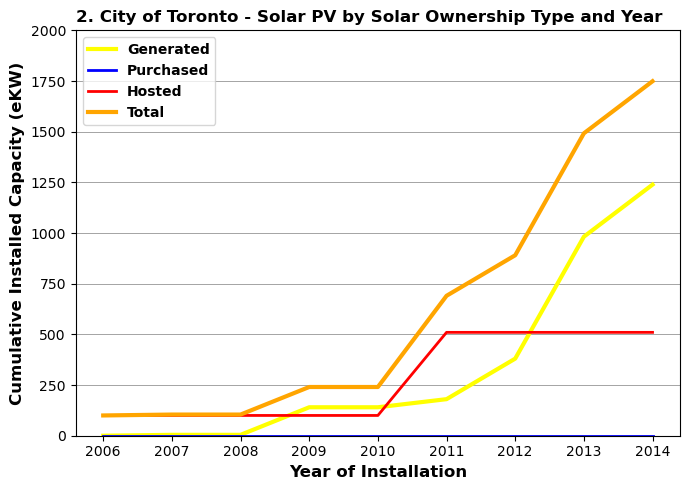

In [11]:
#customizing colours and fonts
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(x,y1, label = 'Generated', linewidth=3, color = 'yellow')
ax.plot(x,y2, label = 'Purchased', linewidth=2, color = 'blue')
ax.plot(x,y3, label = 'Hosted', linewidth=2, color = 'red')
ax.plot(x,y4, label = 'Total', linewidth=3, color = 'orange')
ax.legend(loc='upper left', prop={'weight': 'bold'})
#ax.tick_params(axis = 'x', fontweight = 'bold')
ax.set_title('2. City of Toronto - Solar PV by Solar Ownership Type and Year', fontdict=font1, loc = 'left')
ax.set_ylabel('Cumulative Installed Capacity (eKW)', fontdict=font4) # black seems to provide the best contrast
ax.set_xlabel('Year of Installation', fontdict=font4)
ax.grid(axis = 'y', color = 'gray', linewidth = 0.5, linestyle = '-') # adding grid lines
#someaxes['ax'].annotate('Total dominated by City owned solar generation', xy=(2012.5,1280), xytext=(2007,1260), fontsize=10,arrowprops=dict(facecolor='black', shrink=0.05)) # used in the final version
#ax.annotate('City owned solar generation', xy=(2013,1030), xytext=(2009,1010), fontsize=10,arrowprops=dict(facecolor='black', shrink=0.05)) #used in the final version
plt.ylim((0,2000)) # standardizes the y range
plt.tight_layout()
plt.plot()

This completes Objective #1

OBJECTIVE #2 - Create a mosaic to illustrate the contribution of each Solar Ownership Type to the Total

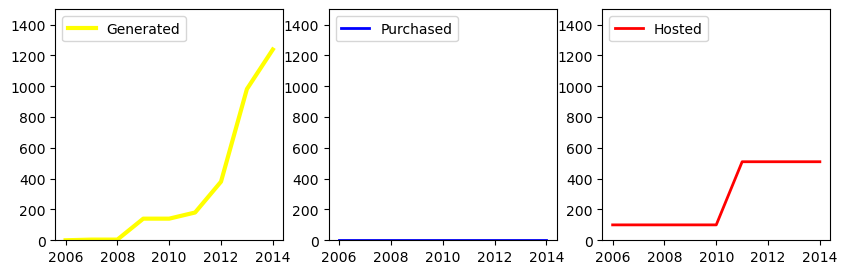

In [12]:
# begin by plotting the three subplots of interest
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, nrows=1, figsize=(10, 3))
ax1.plot(x,y1,label = 'Generated', linewidth=3, color = 'yellow')
ax2.plot(x,y2,label = 'Purchased', linewidth=2, color = 'blue')
ax3.plot(x,y3,label = 'Hosted', linewidth=2, color = 'red')
ax1.set_ylim((0,1500)) # standardize the y range to compare the impacts
ax2.set_ylim((0,1500))
ax3.set_ylim((0,1500))
ax1.legend(loc='upper left')
ax2.legend(loc='upper left')
ax3.legend(loc='upper left')
#fig.show()

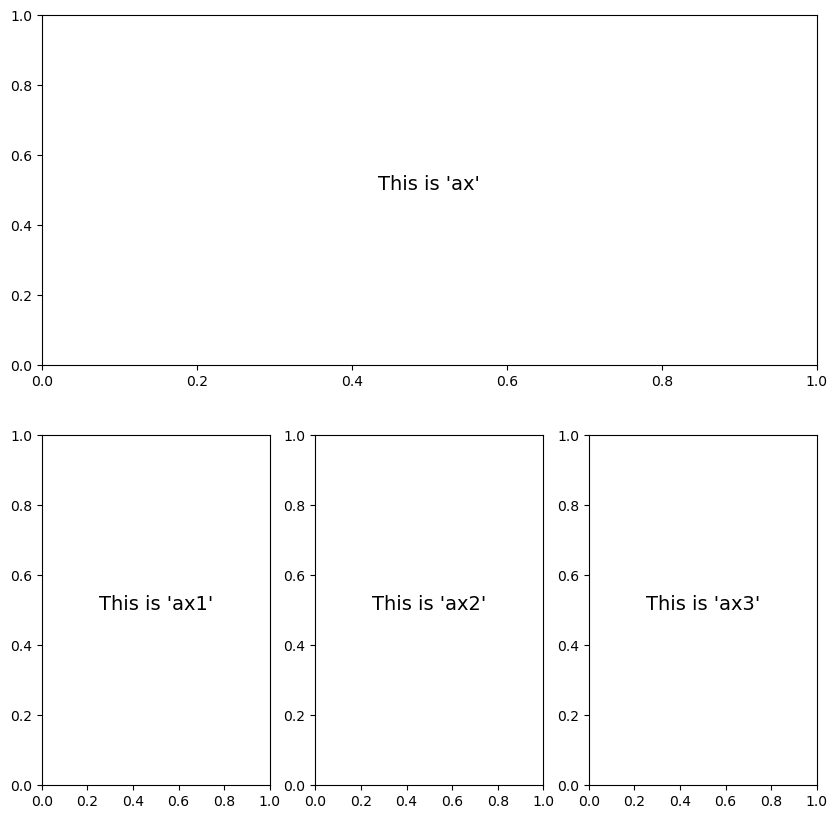

In [13]:
#establish the appropriate mosaic
fig, someaxes = plt.subplot_mosaic([['ax', 'ax', 'ax'], ['ax1','ax2','ax3']], figsize=(10, 10))
for label, ax in someaxes.items():
        ax.text(0.5, 0.5, f'This is {label!r}', 
        fontsize=14, 
        ha = 'center', 
        transform=ax.transAxes)

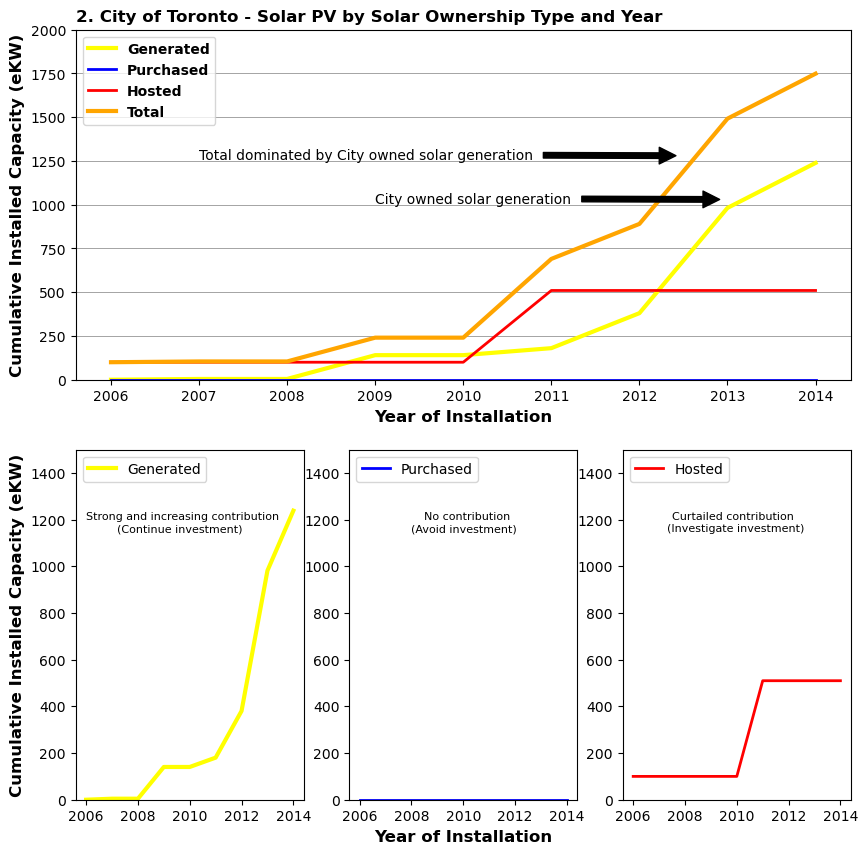

In [14]:
#plot the mosaic bringing together the four plots
fig, someaxes = plt.subplot_mosaic([['ax', 'ax', 'ax'], ['ax1','ax2','ax3']], figsize=(10, 10))
someaxes['ax'].plot(x,y1, label = 'Generated', linewidth=3, color = 'yellow')
someaxes['ax'].plot(x,y2, label = 'Purchased', linewidth=2, color = 'blue')
someaxes['ax'].plot(x,y3, label = 'Hosted', linewidth=2, color = 'red')
someaxes['ax'].plot(x,y4, label = 'Total', linewidth=3, color = 'orange')
someaxes['ax'].legend(loc='upper left', prop={'weight': 'bold'})
someaxes['ax'].set_title('2. City of Toronto - Solar PV by Solar Ownership Type and Year', fontdict=font1, loc = 'left')
someaxes['ax'].set_ylabel('Cumulative Installed Capacity (eKW)', fontdict=font4)
someaxes['ax'].set_xlabel('Year of Installation', fontdict=font4)
someaxes['ax'].grid(axis = 'y', color = 'gray', linewidth = 0.5, linestyle = '-')
someaxes['ax1'].plot(x,y1,label = 'Generated', linewidth=3, color = 'yellow')
someaxes['ax2'].plot(x,y2,label = 'Purchased', linewidth=2, color = 'blue')
someaxes['ax3'].plot(x,y3,label = 'Hosted', linewidth=2, color = 'red')
someaxes['ax1'].set_ylabel('Cumulative Installed Capacity (eKW)', fontdict=font4) #adding y-axis title only to ax1
someaxes['ax2'].set_xlabel('Year of Installation', fontdict=font4) # adding x-axis title only to ax2
someaxes['ax'].annotate('Total dominated by City owned solar generation', xy=(2012.5,1280), xytext=(2007,1260), fontsize=10,arrowprops=dict(facecolor='black', shrink=0.05))
someaxes['ax'].annotate('City owned solar generation', xy=(2013,1030), xytext=(2009,1010), fontsize=10,arrowprops=dict(facecolor='black', shrink=0.05))
someaxes['ax1'].annotate('Strong and increasing contribution', xy=(2006,1200), xytext=(2006,1200), fontsize=8)
someaxes['ax1'].annotate('(Continue investment)', xy=(2007.2,1150), xytext=(2007.2,1150), fontsize=8)
someaxes['ax2'].annotate('No contribution', xy=(2008.5,1200), xytext=(2008.5,1200), fontsize=8)
someaxes['ax2'].annotate('(Avoid investment)', xy=(2008,1150), xytext=(2008,1150), fontsize=8)
someaxes['ax3'].annotate('Curtailed contribution', xy=(2007.5,1200), xytext=(2007.5,1200), fontsize=8)
someaxes['ax3'].annotate('(Investigate investment)', xy=(2007.3,1150), xytext=(2007.3,1150), fontsize=8)
someaxes['ax'].set_ylim(0,2000)
someaxes['ax1'].set_ylim((0,1500))
someaxes['ax2'].set_ylim((0,1500))
someaxes['ax3'].set_ylim((0,1500))
someaxes['ax1'].legend(loc='upper left')
someaxes['ax2'].legend(loc='upper left')
someaxes['ax3'].legend(loc='upper left')

This completed Objective #2. The above graph submitted as visualization #2.